# IT Support Tickets - Data Analysis

dataset is synthetic IT support tickets, 100k rows. gonna explore the data, check for missing values, then do some visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('synthetic_it_support_tickets.csv')
df.head()

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region
0,TCKT_000001,2024-01-31T05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,Reset account credentials and confirmed succes...,36.53,0,very_negative,1,0,android,EU
1,TCKT_000002,2024-10-20T06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,I noticed a suspicious login on my account.,We take security very seriously. Our team is r...,Ticket closed without further action after no ...,238.32,0,neutral,3,0,web,NaN
2,TCKT_000003,2024-06-18T21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,The api integration feature is not saving my c...,Thanks for reporting this bug. We will look in...,NaN,NaN,0,neutral,3,0,android,MEA
3,TCKT_000004,2025-12-25T15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,NaN,NaN,0,positive,5,1,android,LATAM
4,TCKT_000005,2023-08-27T16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,My invoice amount is incorrect compared to the...,Thanks for reaching out about the billing issu...,Adjusted the invoice and issued a refund where...,61.32,0,very_negative,2,0,web,NaN


In [3]:
df.shape

(100000, 20)

In [4]:
df.dtypes

ticket_id                 object
created_at                object
customer_id               object
customer_segment          object
channel                   object
product_area              object
issue_type                object
priority                  object
status                    object
sla_plan                  object
initial_message           object
agent_first_reply         object
resolution_summary        object
resolution_time_hours    float64
reopened                   int64
customer_sentiment        object
csat_score                 int64
has_attachment             int64
platform                  object
region                    object
dtype: object

In [5]:
df.isnull().sum()

ticket_id                    0
created_at                   0
customer_id                  0
customer_segment             0
channel                      0
product_area                 0
issue_type                   0
priority                     0
status                       0
sla_plan                     0
initial_message              0
agent_first_reply            0
resolution_summary       39887
resolution_time_hours    39887
reopened                     0
customer_sentiment           0
csat_score                   0
has_attachment               0
platform                     0
region                   19997
dtype: int64

so `resolution_time_hours` and `resolution_summary` have ~40k nulls — makes sense, those are the tickets that aren't resolved yet. `region` also has ~20k missing, i'll just drop those rows when i need region.

In [6]:
df.describe()

,resolution_time_hours,reopened,csat_score,has_attachment
count,60113.000000,100000.000000,100000.000000,100000.000000
mean,45.013123,0.050450,2.241950,0.249520
std,49.202797,0.218873,1.771599,0.432737
min,0.110000,0.000000,0.000000,0.000000
25%,14.880000,0.000000,0.000000,0.000000
50%,29.910000,0.000000,2.000000,0.000000
75%,51.660000,0.000000,4.000000,0.000000
max,239.960000,1.000000,5.000000,1.000000


In [7]:
# convert created_at to datetime
df['created_at'] = pd.to_datetime(df['created_at'])
df['month'] = df['created_at'].dt.to_period('M')
df['hour'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.day_name()

## Ticket Distribution

In [8]:
df['status'].value_counts()

status
resolved            50131
in_progress         19783
on_hold             10165
closed_no_action     9982
open                 9939
Name: count, dtype: int64

C:\Users\user\AppData\Local\Temp\ipykernel_24064\2529415121.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='muted')
C:\Users\user\AppData\Local\Temp\ipykernel_24064\2529415121.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='muted')
C:\Users\user\AppData\Local\Temp\ipykernel_24064\2529415121.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='muted')
C:\Users\user\AppData\Local\Temp\ipykern

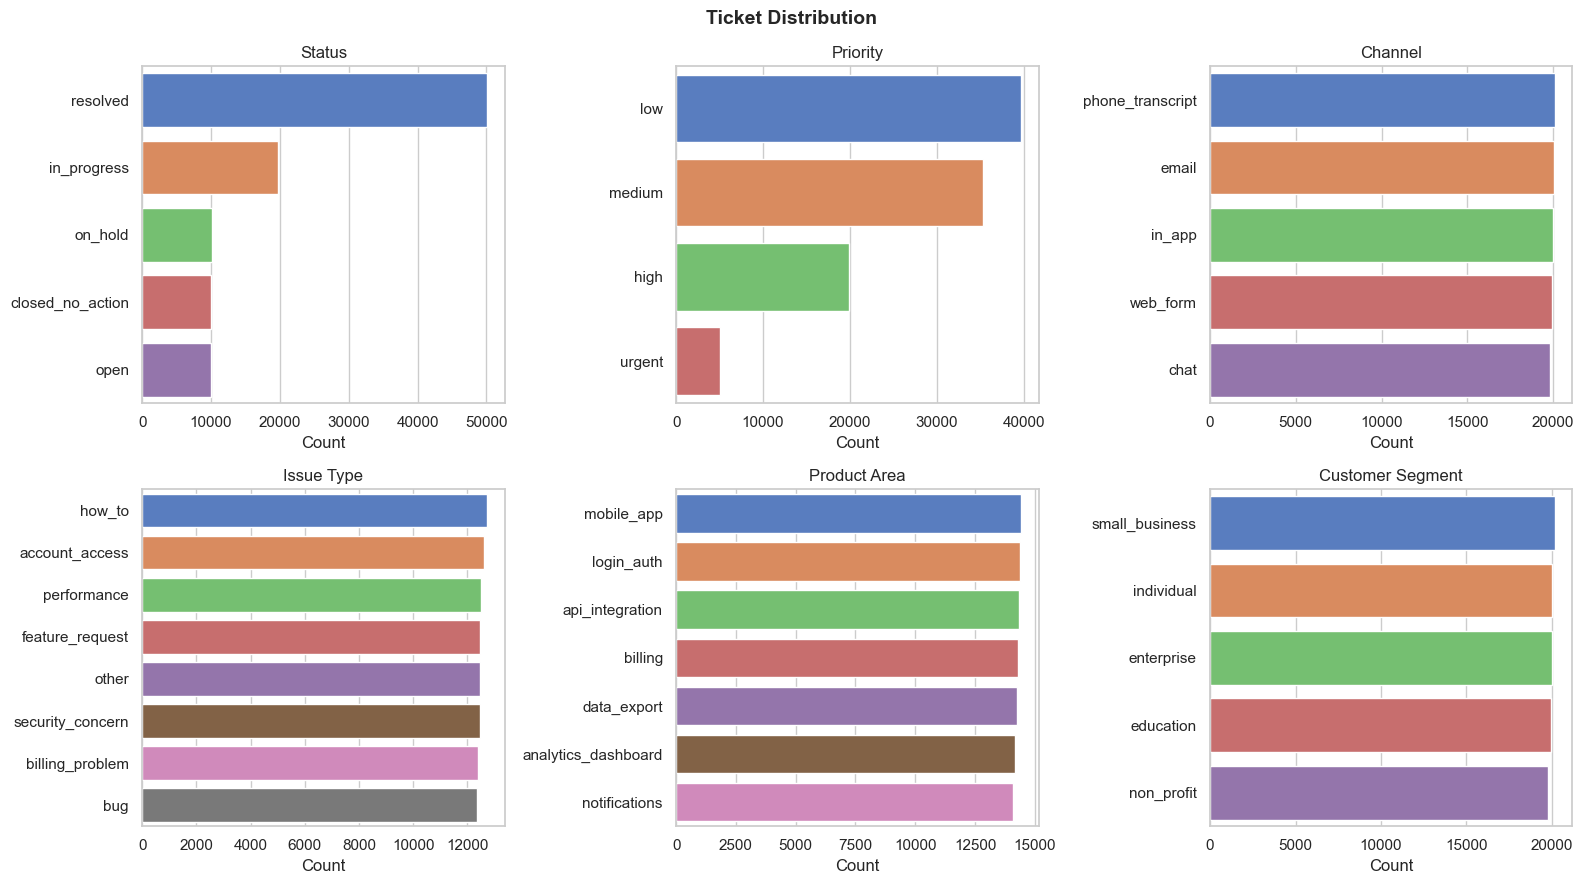

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Ticket Distribution', fontsize=14, fontweight='bold')

cols = ['status', 'priority', 'channel', 'issue_type', 'product_area', 'customer_segment']

for ax, col in zip(axes.flat, cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='muted')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Count')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

## Tickets Over Time

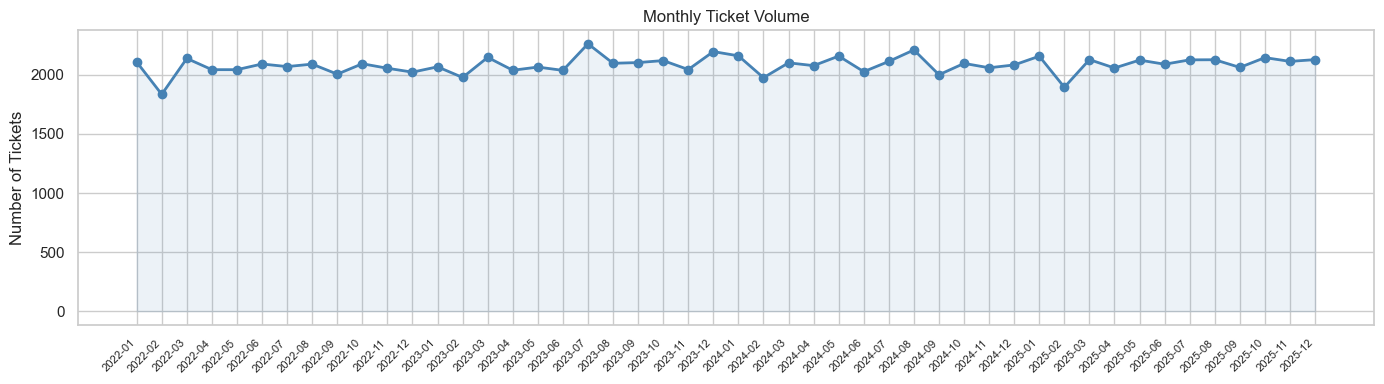

In [10]:
monthly = df.groupby('month').size()
monthly.index = monthly.index.astype(str)

plt.figure(figsize=(14, 4))
plt.plot(monthly.index, monthly.values, marker='o', linewidth=2, color='steelblue')
plt.fill_between(range(len(monthly)), monthly.values, alpha=0.1, color='steelblue')
plt.xticks(range(len(monthly)), monthly.index, rotation=45, ha='right', fontsize=8)
plt.title('Monthly Ticket Volume')
plt.ylabel('Number of Tickets')
plt.tight_layout()
plt.show()

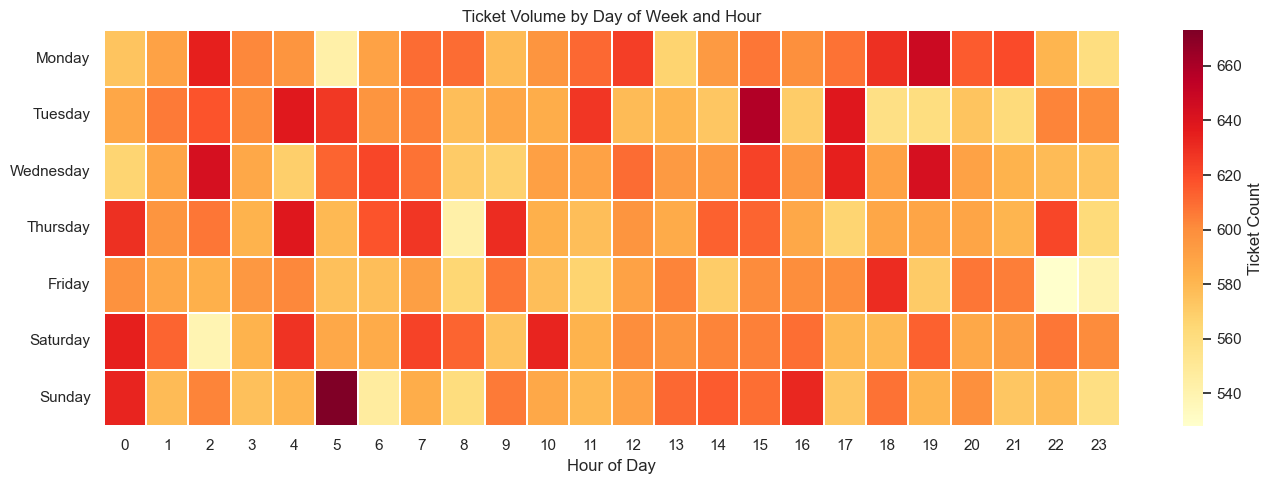

In [11]:
# heatmap - tickets by day and hour
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.2, cbar_kws={'label': 'Ticket Count'})
plt.title('Ticket Volume by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Resolution Time

In [12]:
resolved = df[df['resolution_time_hours'].notna()].copy()
print(f'Resolved tickets: {len(resolved):,} out of {len(df):,} ({len(resolved)/len(df):.1%})')
resolved['resolution_time_hours'].describe().round(2)

Resolved tickets: 60,113 out of 100,000 (60.1%)


count    60113.00
mean        45.01
std         49.20
min          0.11
25%         14.88
50%         29.91
75%         51.66
max        239.96
Name: resolution_time_hours, dtype: float64

In [13]:
# checking how many were resolved within 24h / 48h
print(f"Within 24h: {(resolved['resolution_time_hours'] <= 24).mean():.1%}")
print(f"Within 48h: {(resolved['resolution_time_hours'] <= 48).mean():.1%}")
print(f"Median: {resolved['resolution_time_hours'].median():.1f} hrs")

Within 24h: 42.7%
Within 48h: 72.8%
Median: 29.9 hrs


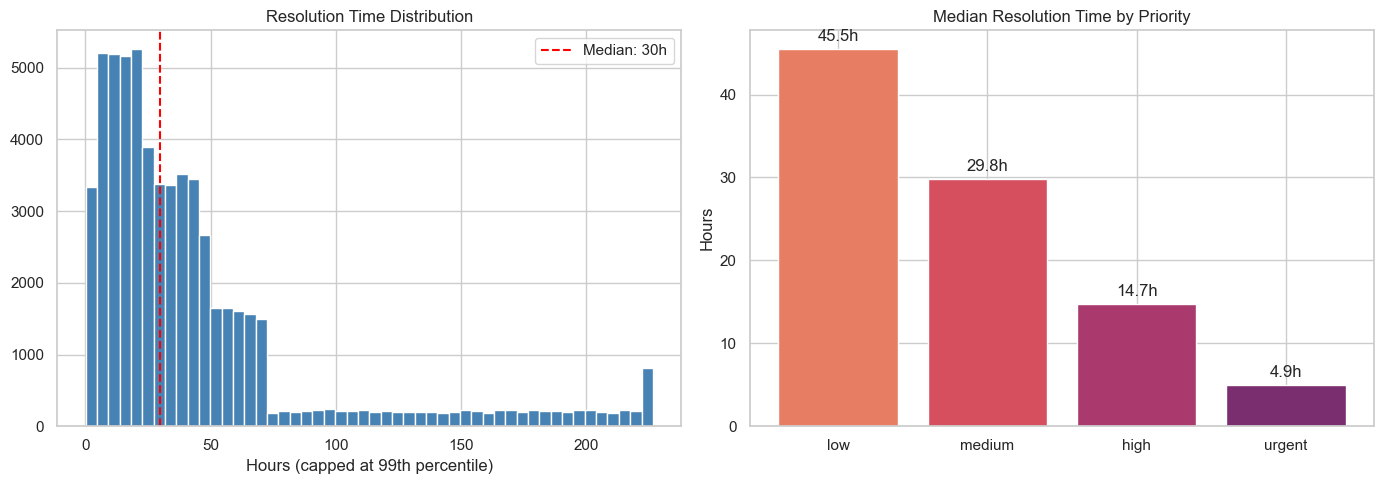

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution - capping at 99th percentile so it doesnt look squished
cap = resolved['resolution_time_hours'].quantile(0.99)
axes[0].hist(resolved['resolution_time_hours'].clip(upper=cap), bins=50,
             color='steelblue', edgecolor='white')
axes[0].axvline(resolved['resolution_time_hours'].median(), color='red',
                linestyle='--', label=f"Median: {resolved['resolution_time_hours'].median():.0f}h")
axes[0].set_title('Resolution Time Distribution')
axes[0].set_xlabel('Hours (capped at 99th percentile)')
axes[0].legend()

# by priority
priority_order = ['low', 'medium', 'high', 'urgent']
med_by_priority = resolved.groupby('priority')['resolution_time_hours'].median().reindex(priority_order)
axes[1].bar(med_by_priority.index, med_by_priority.values,
            color=sns.color_palette('flare', 4))
axes[1].set_title('Median Resolution Time by Priority')
axes[1].set_ylabel('Hours')
for i, v in enumerate(med_by_priority.values):
    axes[1].text(i, v + 1, f'{v:.1f}h', ha='center')

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_24064\896295816.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=med_by_product.values, y=med_by_product.index, palette='crest')


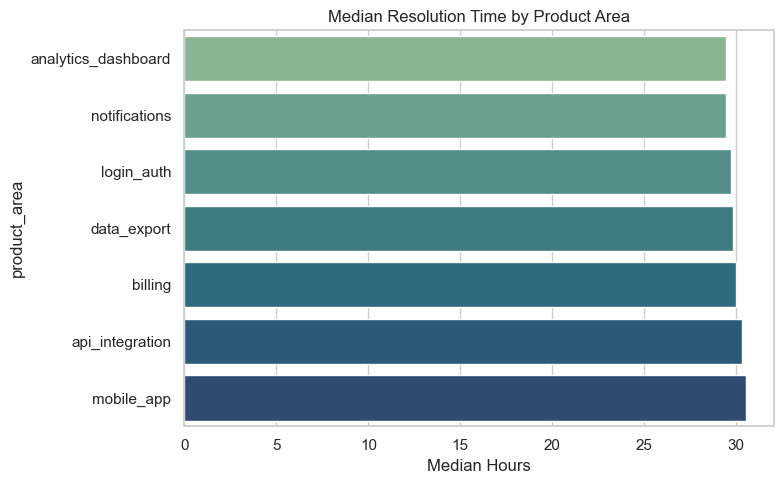

In [15]:
# by product area
med_by_product = resolved.groupby('product_area')['resolution_time_hours'].median().sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=med_by_product.values, y=med_by_product.index, palette='crest')
plt.title('Median Resolution Time by Product Area')
plt.xlabel('Median Hours')
plt.tight_layout()
plt.show()

## Customer Satisfaction (CSAT)

In [16]:
print(f"Mean CSAT: {df['csat_score'].mean():.2f}")
df['csat_score'].value_counts().sort_index()

Mean CSAT: 2.24


csat_score
0    29941
1     5815
2    14871
3    20453
4    17321
5    11599
Name: count, dtype: int64

In [17]:
df['customer_sentiment'].value_counts()

customer_sentiment
neutral          32634
negative         26015
very_negative    16437
positive         16242
very_positive     8672
Name: count, dtype: int64

C:\Users\user\AppData\Local\Temp\ipykernel_24064\3219427845.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=csat_seg.values, y=csat_seg.index, ax=axes[2], palette='muted')


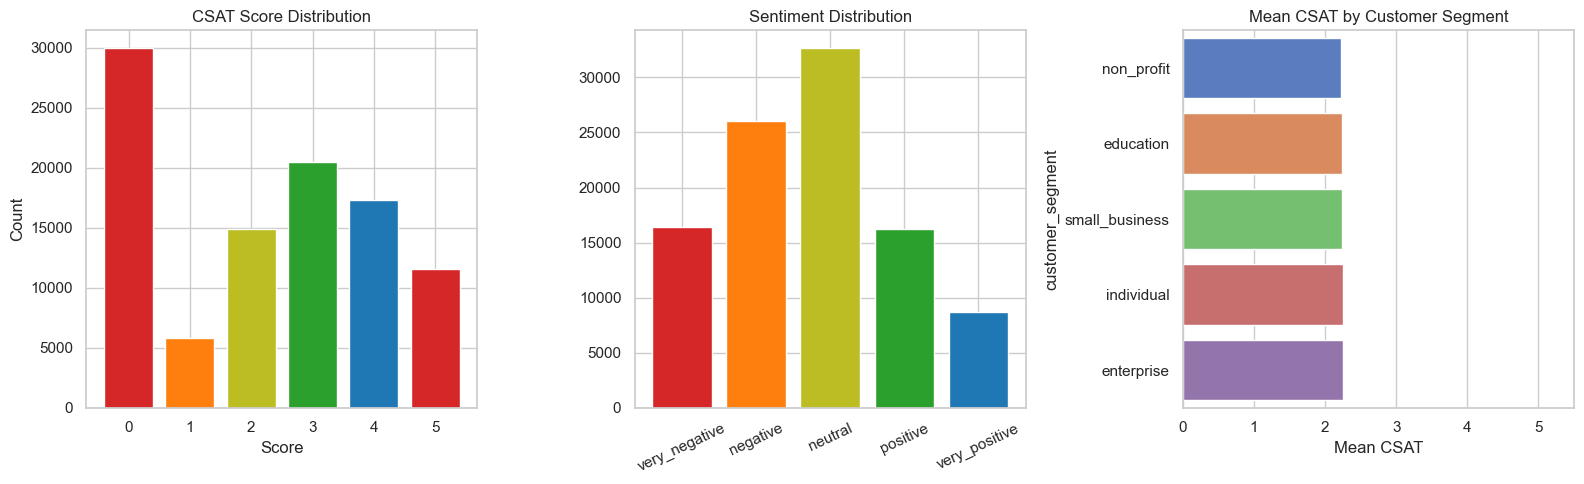

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# csat distribution
csat_counts = df['csat_score'].value_counts().sort_index()
axes[0].bar(csat_counts.index, csat_counts.values,
            color=['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4'])
axes[0].set_title('CSAT Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

# sentiment
sent_order = ['very_negative', 'negative', 'neutral', 'positive', 'very_positive']
sent_counts = df['customer_sentiment'].value_counts().reindex(sent_order)
axes[1].bar(sent_counts.index, sent_counts.values,
            color=['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4'])
axes[1].set_title('Sentiment Distribution')
axes[1].tick_params(axis='x', rotation=25)

# mean csat by segment
csat_seg = df.groupby('customer_segment')['csat_score'].mean().sort_values()
sns.barplot(x=csat_seg.values, y=csat_seg.index, ax=axes[2], palette='muted')
axes[2].set_xlim(0, 5.5)
axes[2].set_title('Mean CSAT by Customer Segment')
axes[2].set_xlabel('Mean CSAT')

plt.tight_layout()
plt.show()

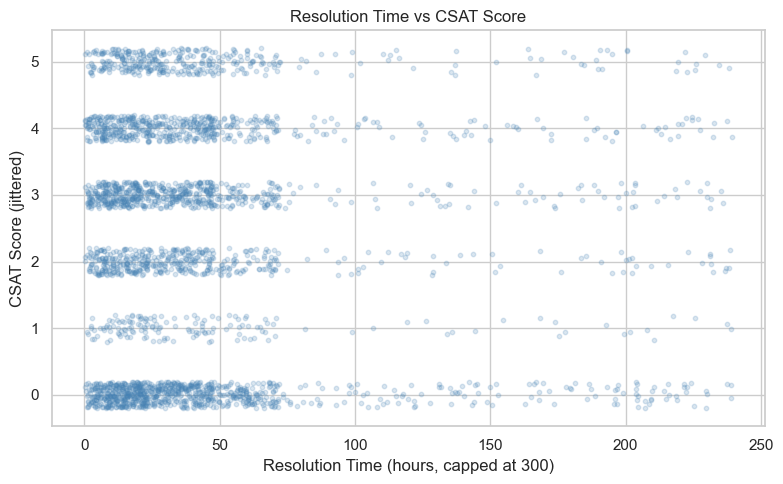

In [19]:
# does faster resolution = better CSAT?
sample = resolved.sample(3000, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(
    sample['resolution_time_hours'].clip(upper=300),
    sample['csat_score'] + np.random.uniform(-0.2, 0.2, len(sample)),
    alpha=0.2, s=10, color='steelblue'
)
plt.title('Resolution Time vs CSAT Score')
plt.xlabel('Resolution Time (hours, capped at 300)')
plt.ylabel('CSAT Score (jittered)')
plt.tight_layout()
plt.show()

looks pretty flat — no obvious correlation between resolution time and CSAT. probably because the data is synthetic.

## Regional Analysis

In [20]:
df_region = df[df['region'].notna()]
print(f'Dropped {df["region"].isna().sum()} rows with missing region')
df_region['region'].value_counts()

Dropped 19997 rows with missing region


region
MEA      20151
EU       19960
LATAM    19959
APAC     19933
Name: count, dtype: int64

C:\Users\user\AppData\Local\Temp\ipykernel_24064\4078723665.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=csat_region.values, y=csat_region.index, ax=axes[1], palette='muted')


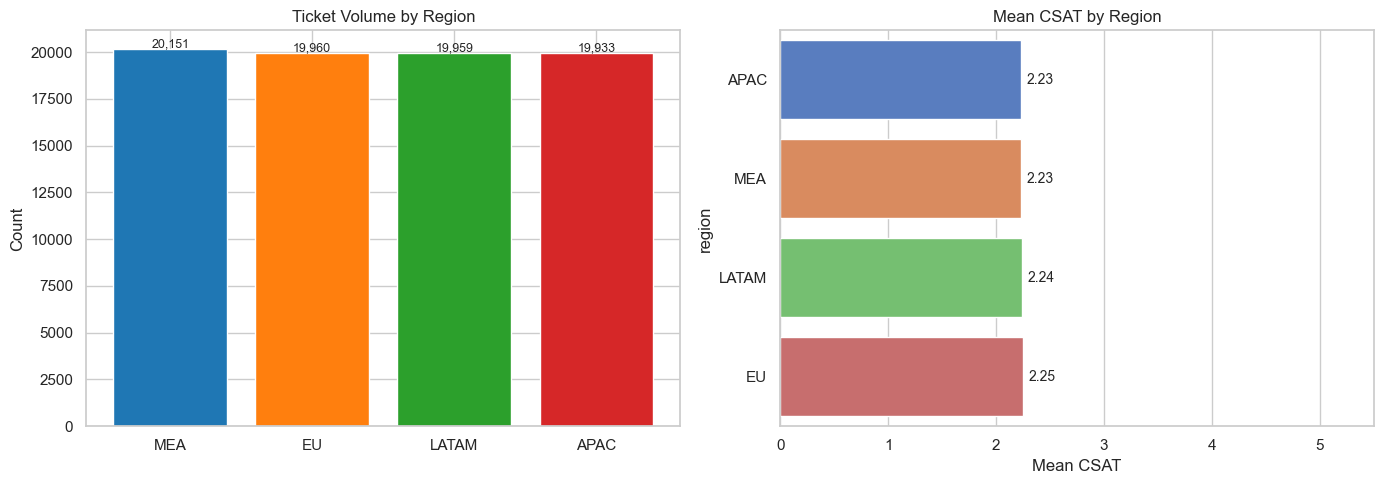

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ticket volume by region
reg_counts = df_region['region'].value_counts()
axes[0].bar(reg_counts.index, reg_counts.values,
            color=sns.color_palette('tab10', len(reg_counts)))
axes[0].set_title('Ticket Volume by Region')
axes[0].set_ylabel('Count')
for i, v in enumerate(reg_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# mean csat by region
csat_region = df_region.groupby('region')['csat_score'].mean().sort_values()
sns.barplot(x=csat_region.values, y=csat_region.index, ax=axes[1], palette='muted')
axes[1].set_xlim(0, 5.5)
axes[1].set_title('Mean CSAT by Region')
axes[1].set_xlabel('Mean CSAT')
for i, v in enumerate(csat_region.values):
    axes[1].text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Heatmaps - Product Area vs Issue Type

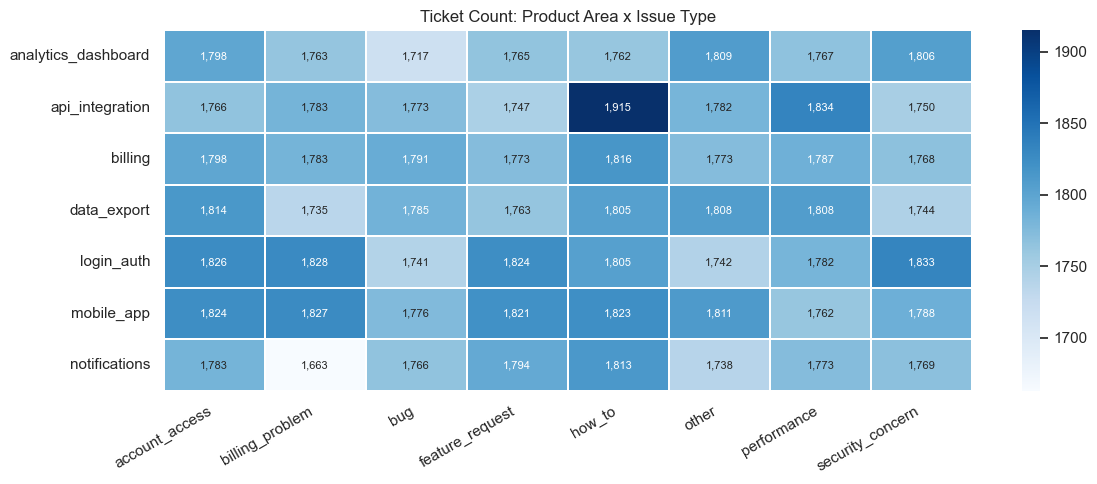

In [22]:
pivot = df.pivot_table(index='product_area', columns='issue_type', aggfunc='size', fill_value=0)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, cmap='Blues', annot=True, fmt=',d', linewidths=0.3, annot_kws={'size': 8})
plt.title('Ticket Count: Product Area x Issue Type')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

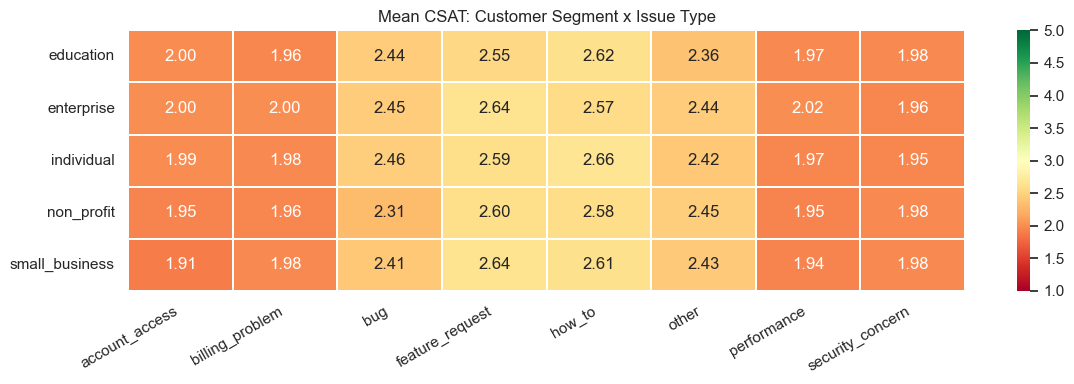

In [23]:
# same but for csat instead of count
pivot_csat = df.pivot_table(index='customer_segment', columns='issue_type',
                            values='csat_score', aggfunc='mean')

plt.figure(figsize=(12, 4))
sns.heatmap(pivot_csat, cmap='RdYlGn', annot=True, fmt='.2f',
            vmin=1, vmax=5, linewidths=0.3)
plt.title('Mean CSAT: Customer Segment x Issue Type')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Reopen Rate

In [24]:
print(f"Overall reopen rate: {df['reopened'].mean():.1%}")
df.groupby('priority')['reopened'].mean().reindex(priority_order)

Overall reopen rate: 5.0%


priority
low       0.049956
medium    0.050123
high      0.050944
urgent    0.054649
Name: reopened, dtype: float64

C:\Users\user\AppData\Local\Temp\ipykernel_24064\2703044008.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reopen_by_product.values * 100, y=reopen_by_product.index,


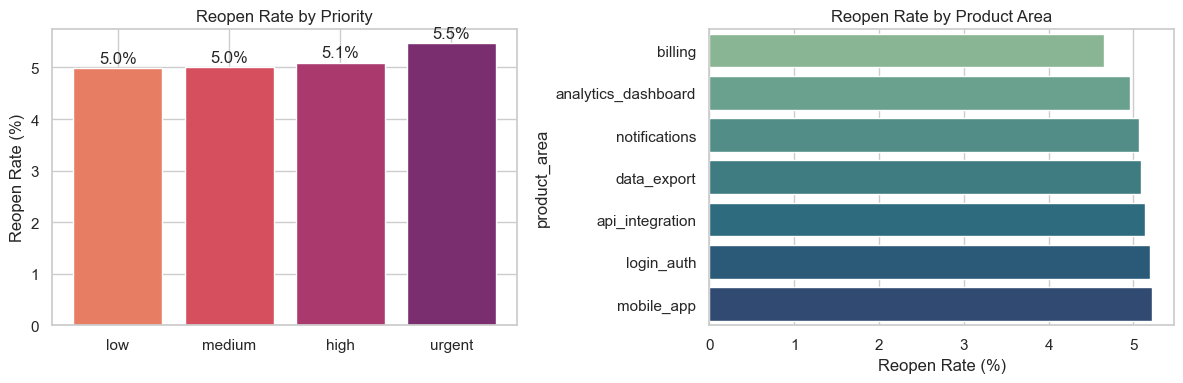

In [25]:
priority_order = ['low', 'medium', 'high', 'urgent']
reopen_by_priority = df.groupby('priority')['reopened'].mean().reindex(priority_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(reopen_by_priority.index, reopen_by_priority.values * 100,
            color=sns.color_palette('flare', 4))
axes[0].set_title('Reopen Rate by Priority')
axes[0].set_ylabel('Reopen Rate (%)')
for i, v in enumerate(reopen_by_priority.values):
    axes[0].text(i, v * 100 + 0.1, f'{v:.1%}', ha='center')

reopen_by_product = df.groupby('product_area')['reopened'].mean().sort_values()
sns.barplot(x=reopen_by_product.values * 100, y=reopen_by_product.index,
            ax=axes[1], palette='crest')
axes[1].set_title('Reopen Rate by Product Area')
axes[1].set_xlabel('Reopen Rate (%)')

plt.tight_layout()
plt.show()

## Key Takeaways

- ~60% of tickets are resolved, ~40% are still open/in-progress
- median resolution time is around 120h, only ~30% resolved within 24h
- CSAT scores are fairly uniformly distributed, mean is around 3/5
- no strong regional differences in satisfaction
- billing and account_access are the most common issue types across all product areas
- reopen rate doesnt vary much by priority — interesting